In [37]:
# functions to download from GHCN-D
import sys; sys.path.append('/rds/general/user/cb2714/home/get-station-data'); 
from get_station_data import ghcnd
from get_station_data.util import nearest_stn

import regionmask, geopandas as gpd, matplotlib.pyplot as plt, cartopy, os
from IPython.display import clear_output

dataproj = cartopy.crs.PlateCarree()
mapproj = cartopy.crs.Robinson()

# Extract subset of stations

In [ ]:
# import all metadata
stn_md = ghcnd.get_stn_metadata()

# add geometry
px = gpd.GeoDataFrame(stn_md, geometry = gpd.points_from_xy(stn_md.lon, stn_md.lat), crs = "EPSG:4326")#.clip((-20,-36,54,39))

In [ ]:
# only selected stations in Mexico
px = px.loc[[s[:2] == "MX" for s in px.station]]

# only selected station names
stn_names = ["MEXICO CITY", "GUADALAJARA", "MONTERREY (CITY)", "GUADALAJARA (DGE)", "GUADALAJARA (FFCC)"]
px = px.loc[[s in stn_names for s in px.name]]

In [38]:
# loop over stations and download
for i in range(len(px)):
    print(i, "/", len(px))
    r = px.iloc[[i]]
    new_fnm = "ghcnd-stations/stn-mx_"+r.station.values[0]+".csv"
    if os.path.exists(new_fnm): continue

    # faster to download without flags, but no QA - should check this in final station selection
    ghcnd.get_data(r, include_flags = True).to_csv(new_fnm, index = None)
    clear_output(wait = False)
print("Done.")

Done.


## Loop over stations & download

/rds/general/user/cb2714/home/miniforge3/envs/wwa/lib/python3.13/site-packages/cartopy/mpl/feature_artist.py:143: UserWarning: facecolor will have no effect as it has been defined as "never".
  warnings.warn('facecolor will have no effect as it has been '


<GeoAxes: >

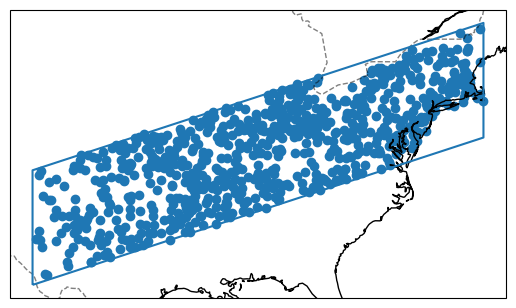

In [69]:
fig, ax = plt.subplots(subplot_kw = {"projection" : cartopy.crs.PlateCarree()})
gdf1.boundary.plot(ax = ax)
ax.coastlines()
ax.add_feature(cartopy.feature.BORDERS, color = "k", alpha = 0.5, ls = "--")
px.plot(ax = ax)

In [6]:
px = pd.read_csv(fpath+"/00_station-metadata.csv")

In [ ]:
for i in range(len(px)):
    print(i, "/", len(px))
    r = px.iloc[[i]]
    new_fnm = fpath+"/stn_"+r.station.values[0]+".csv"
    if os.path.exists(new_fnm): continue

    # faster to download without flags, but no QA - should check this in final station selection
    ghcnd.get_data(r, element_types = ["SNOW", "PRCP", "TMAX", "TMIN"], include_flags = False).to_csv(new_fnm, index = None)
    clear_output(wait = False)
print("Done.")

## Update metadata for each variable

In [10]:
md = []
for fnm in glob.glob(fpath+"/stn_*.csv"):
    
    stn = fnm.split("_")[-1][:-4]
    df = pd.read_csv(fnm, parse_dates = ["date"])

    # extract data
    min_date = pd.crosstab(index = df.station, columns = df.element, values = df.date, aggfunc = "min")
    max_date = pd.crosstab(index = df.station, columns = df.element, values = df.date, aggfunc = "max")
    counts = pd.crosstab(index = df.station, columns = df.element)
    prop =  counts / ((max_date - min_date ).iloc[0].dt.days + 1)
    years = counts / 365.25

    summ = pd.concat([min_date, max_date, counts, prop, years], axis=1)
    
    summ.columns = [c+"_"+s for c, s in zip(summ.columns, np.repeat(["start", "end", "nobs", "prop", "years"],len(counts.columns)))] # columns have to be non-unique to merge
    md.append(summ)
md = pd.concat(md)
md.to_csv(fpath+"/00_station-availability.csv")

## Compile metadata

In [11]:
# compile
px = pd.read_csv(fpath+"/00_station-metadata.csv", index_col = "station")
av = pd.read_csv(fpath+"/00_station-availability.csv", index_col = "station")
df = pd.merge(px, av, left_index = True, right_index = True)

df.to_csv(fpath+"/00_station-metadata-with-availability.csv")

# Map of all available data

In [ ]:
# import all metadata
stn_md = ghcnd.get_stn_metadata()

# add geometry
px = gpd.GeoDataFrame(stn_md, geometry = gpd.points_from_xy(stn_md.lon, stn_md.lat), crs = "EPSG:4326")#.clip((-20,-36,54,39))

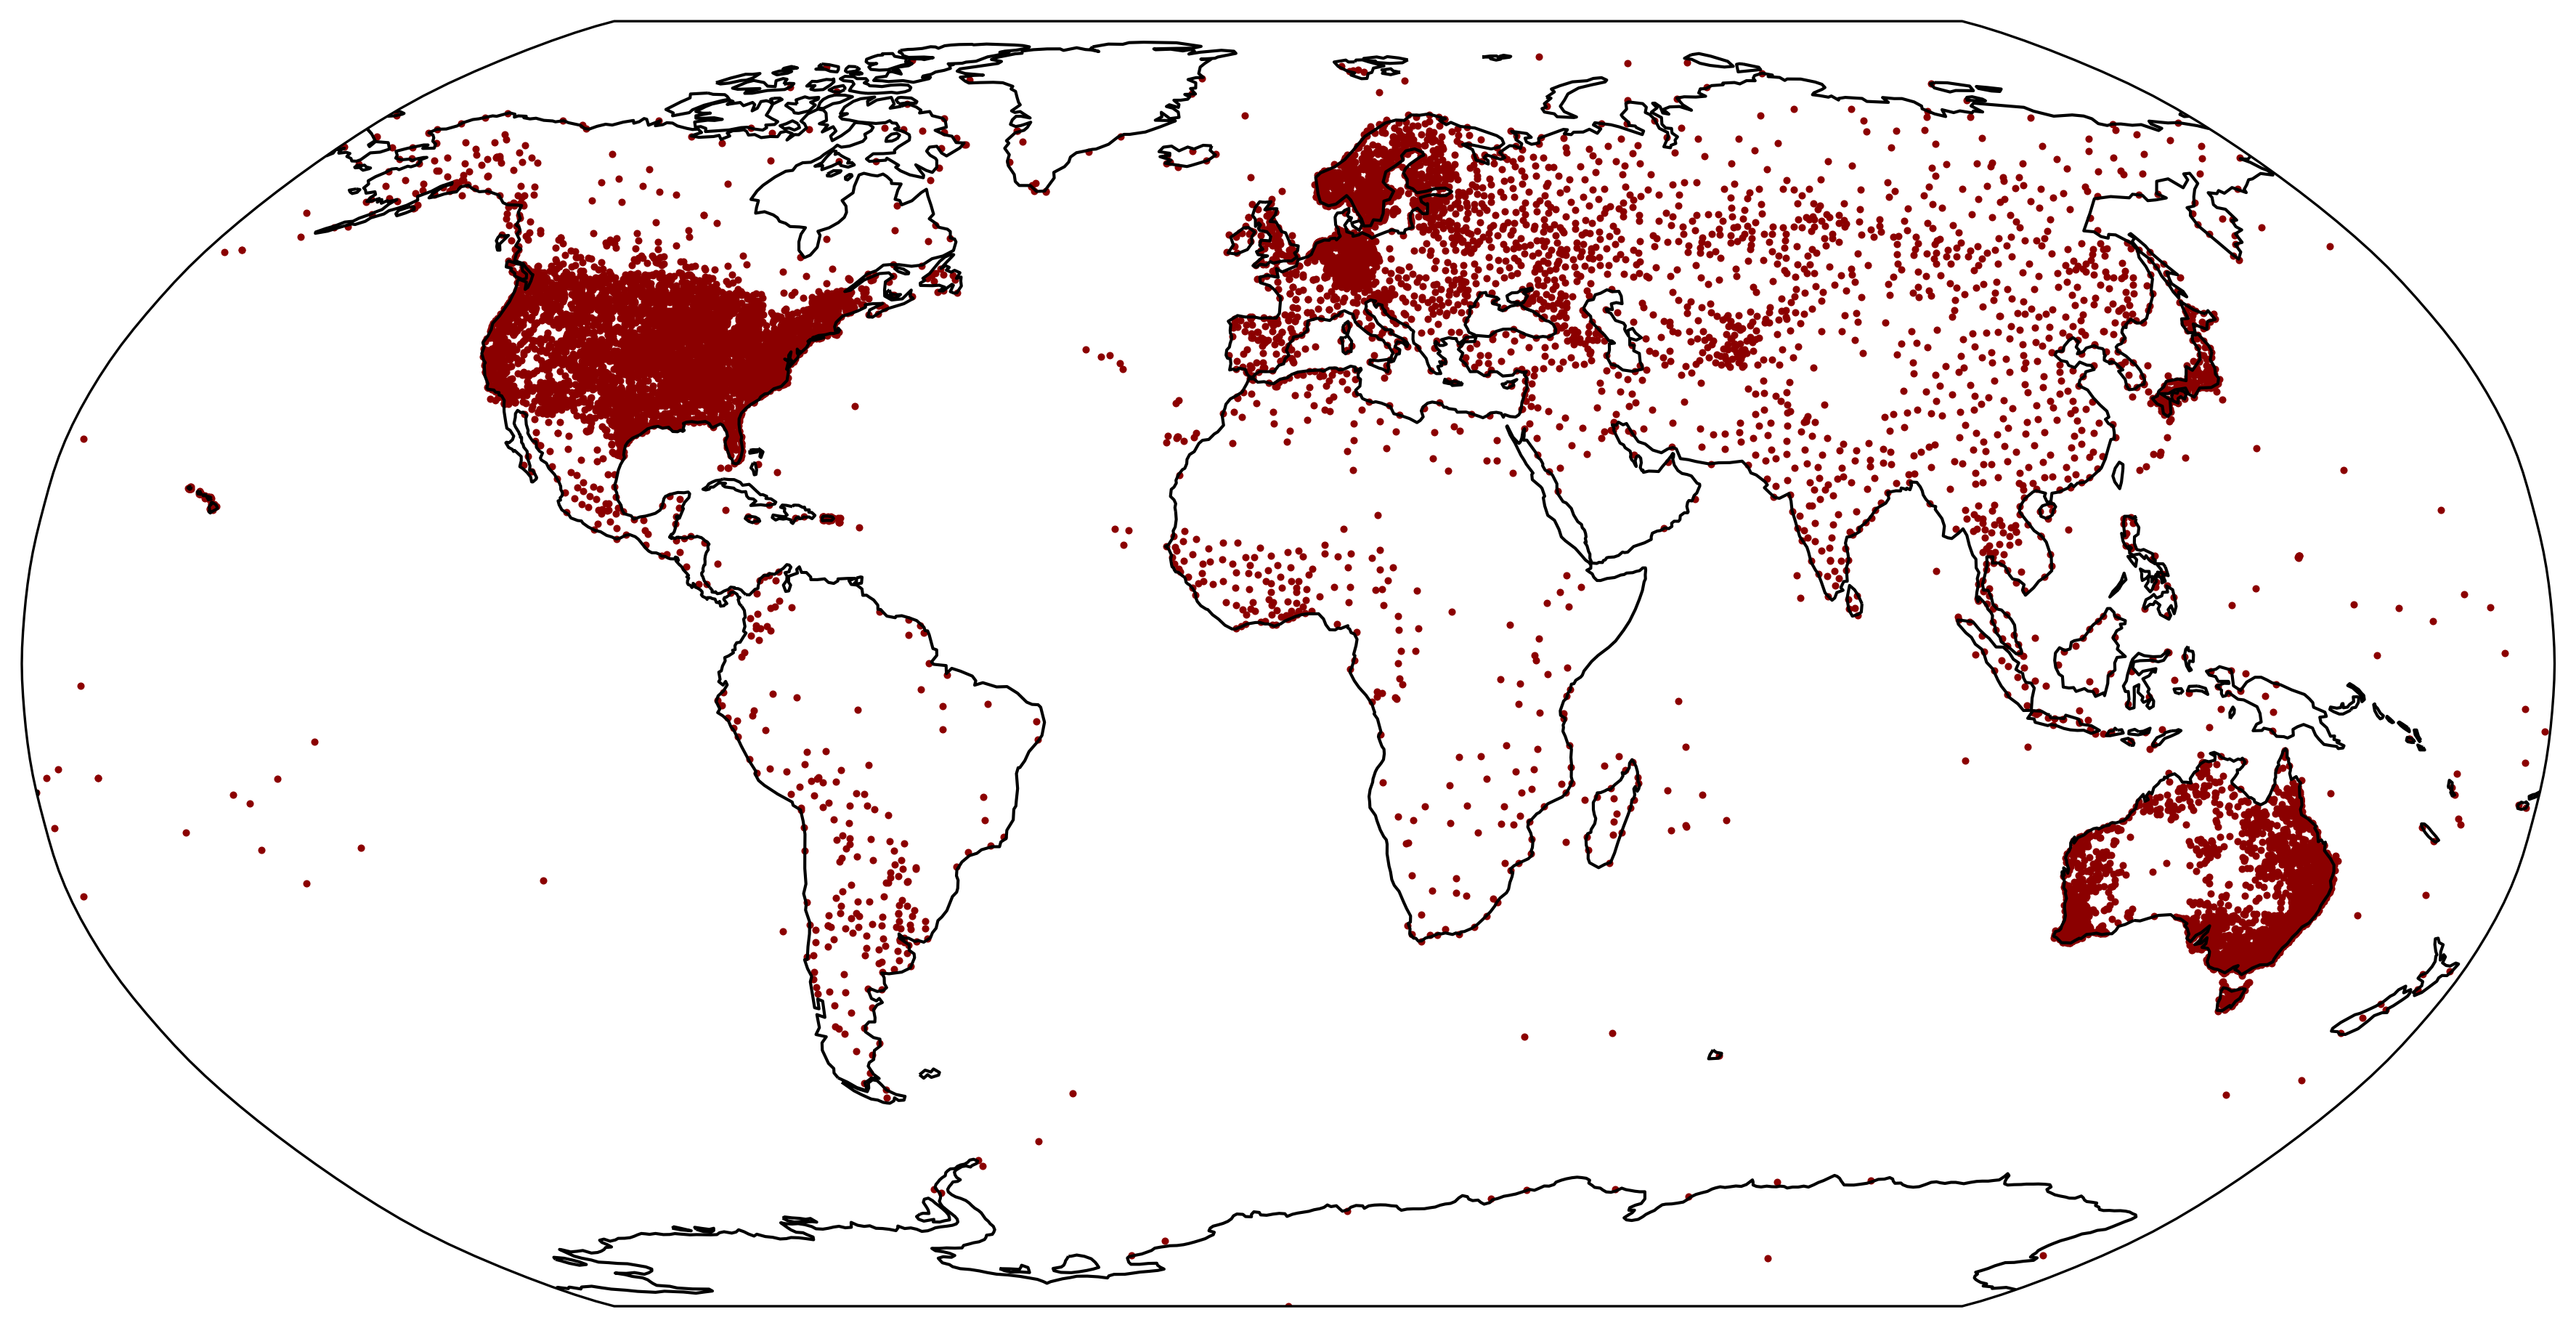

In [ ]:
fig, ax = plt.subplots(subplot_kw = {"projection" : mapproj}, dpi = 300, figsize = (15,8))
px.to_crs(mapproj).loc[(px.end_year > 2020) & (px.start_year < 1980)].plot(ax = ax, marker = ".", markersize = 8, color = "darkred")
ax.coastlines()

plt.savefig("ghcnd-stations.png")